# Disease Sample Scoring Pipeline

| Branch | 모델 | Score | 해석 |
|--------|------|-------|------|
| NBI (det≥10%) | GAMLSS NBI | z_nbi | 발현량 이상도 (calibrated) |
| Logistic (1-10%) | Logistic Regression | z_logistic | 검출 확률 이상도 |
| Rare (det<1%) | Pooled covariate GLM (Poisson) | z_rare | 희소 발현 이상도 (covariate-calibrated) |

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config
from pipeline import data_prep, scoring, plots

In [2]:
engine = scoring.load_engine()
print(f'  NBI genes : {len(engine.count_genes):,}   Logistic : {len(engine.logistic_genes):,}'
      f'   Rare : {len(engine.rare_genes):,}')

Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (20097 fitted genes)
  NBI genes : 16,570   Logistic : 2,968   Rare : 559


In [3]:
adata = data_prep.load_adata()
is_hc, phenotypes, _ = data_prep.make_phenotypes(adata)
is_dis = ~is_hc
Y = data_prep.count_matrix(adata)
X_raw = data_prep.bias_matrix(adata)
sample_ids = adata.obs_names.tolist()
gene_names = adata.var_names.tolist()
dis_idx = np.where(is_dis)[0]
dis_names = [sample_ids[i] for i in dis_idx]
dis_pheno = phenotypes[dis_idx]
print(f'HC: {is_hc.sum()}  Disease: {is_dis.sum()}')
print(pd.Series(dis_pheno).value_counts().to_string())

HC: 693  Disease: 913
CAD_HF+ (Ward)                      116
CAD_HF- (Ward)                      108
Tuberculosis (Chang)                103
ME/CFS (Gardella)                    90
Pancreatitis (Moore)                 81
Pancreatic Cancer (Moore)            74
Pre-eclampsia (Moufarrej)            62
Colorectal Cancer (Chen)             41
Lung Cancer (Chen)                   33
Stomach Cancer (Chen)                29
Liver Cancer (Roskams-Hieter)        28
Esophagus Cancer (Chen)              26
MM (Roskams-Hieter)                  18
Other Cancer (Moore)                 18
Liver Cancer (Chen)                  16
HIV (Chang)                          13
ICI-treated Cancer (Raissadati)      11
ICI-m (Raissadati)                   11
HIV + Tuberculosis (Chang)           11
MGUS (Roskams-Hieter)                 8
Pancreatic Cancer (Reggiardo)         6
Liver Cirrhosis (Roskams-Hieter)      4
Liver Cancer (Block)                  4
Liver Cirrhosis (Block)               1
Esophagus Cancer (

In [4]:
def score_sample(sample_idx):
    df = scoring.score_all(engine, gene_names,
                           X_raw[[sample_idx]], Y[[sample_idx]],
                           [sample_ids[sample_idx]], [phenotypes[sample_idx]], min_abs_score=0.0)
    return df.drop(columns=['sample', 'phenotype'])

print('Scorer ready.')

Scorer ready.


In [5]:
print('plots.plot_sample(df, sample_id, phenotype)')

plots.plot_sample(df, sample_id, phenotype)



Scoring Liver Cancer (Chen): SRR14506726
  Flagged genes: 263
              gene    score score_type  raw_count
ENSG00000092377.15 7.034487   rare_glm       11.0
 ENSG00000142513.6 7.034487   rare_glm        9.0
 ENSG00000150750.9 7.034487   rare_glm       12.0
 ENSG00000172208.7 7.034487   rare_glm       10.0
ENSG00000185681.14 7.034487   rare_glm       36.0


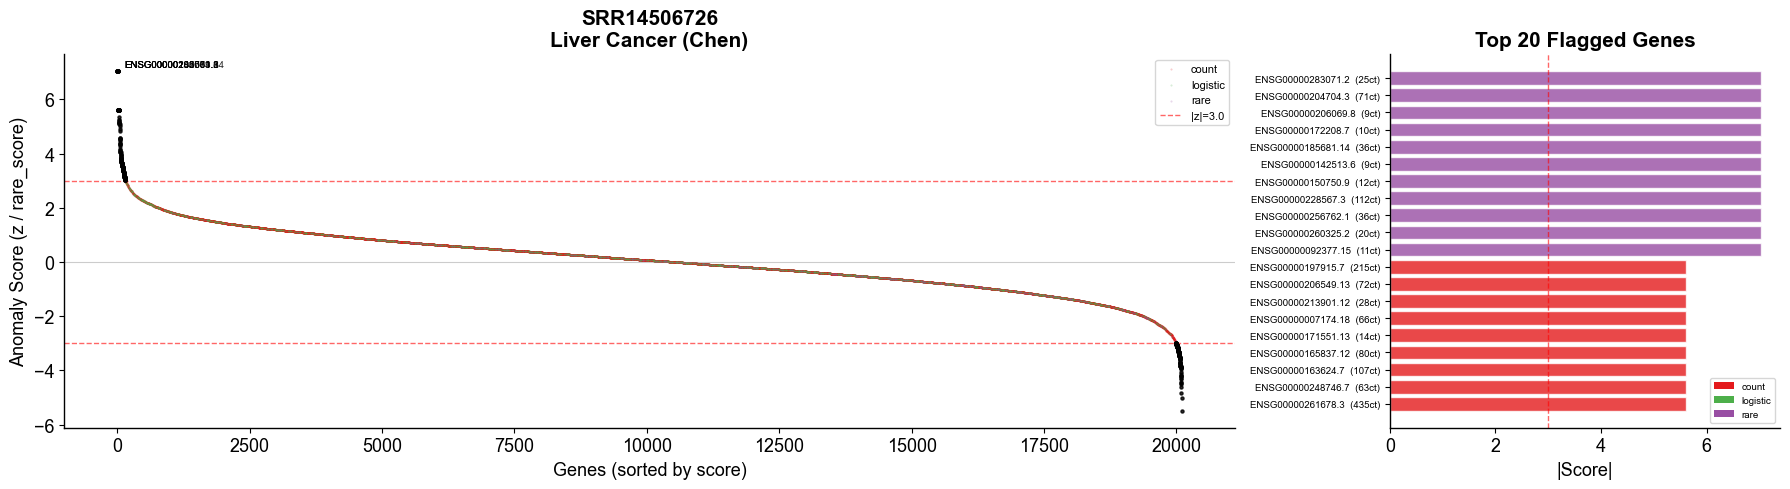


Scoring Pancreatic Cancer (Moore): SRR29803839
  Flagged genes: 46
              gene    score score_type  raw_count
ENSG00000204296.13 5.612001      nbi_z       58.0
 ENSG00000248329.7 5.612001      nbi_z        4.0
ENSG00000154274.16 5.057833      nbi_z       96.0
 ENSG00000284931.1 4.548844      nbi_z    70420.0
ENSG00000008323.17 3.926100      nbi_z       79.0


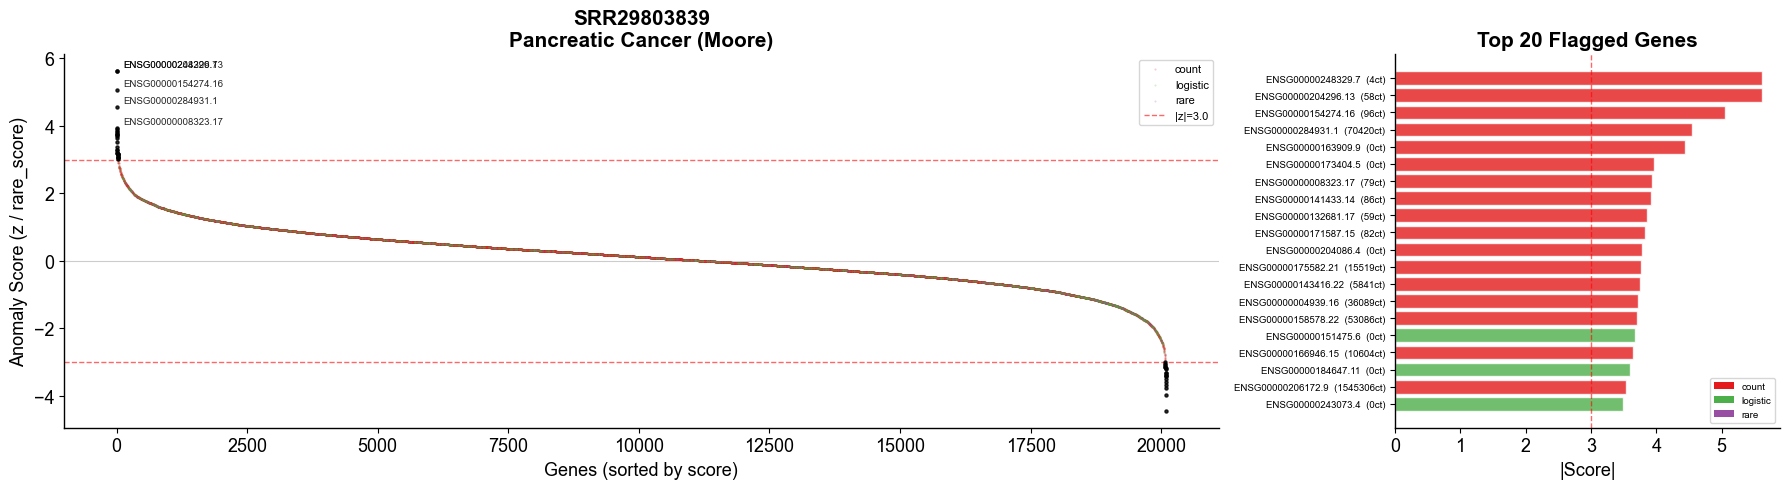


Scoring Tuberculosis (Chang): SRR28475979
  Flagged genes: 95
              gene    score score_type  raw_count
 ENSG00000171459.4 5.927118   rare_glm        3.0
ENSG00000142657.22 5.612001      nbi_z     1268.0
ENSG00000021355.14 5.501016      nbi_z     1218.0
ENSG00000143546.11 5.331437      nbi_z    16328.0
ENSG00000100504.18 5.097613      nbi_z     1001.0


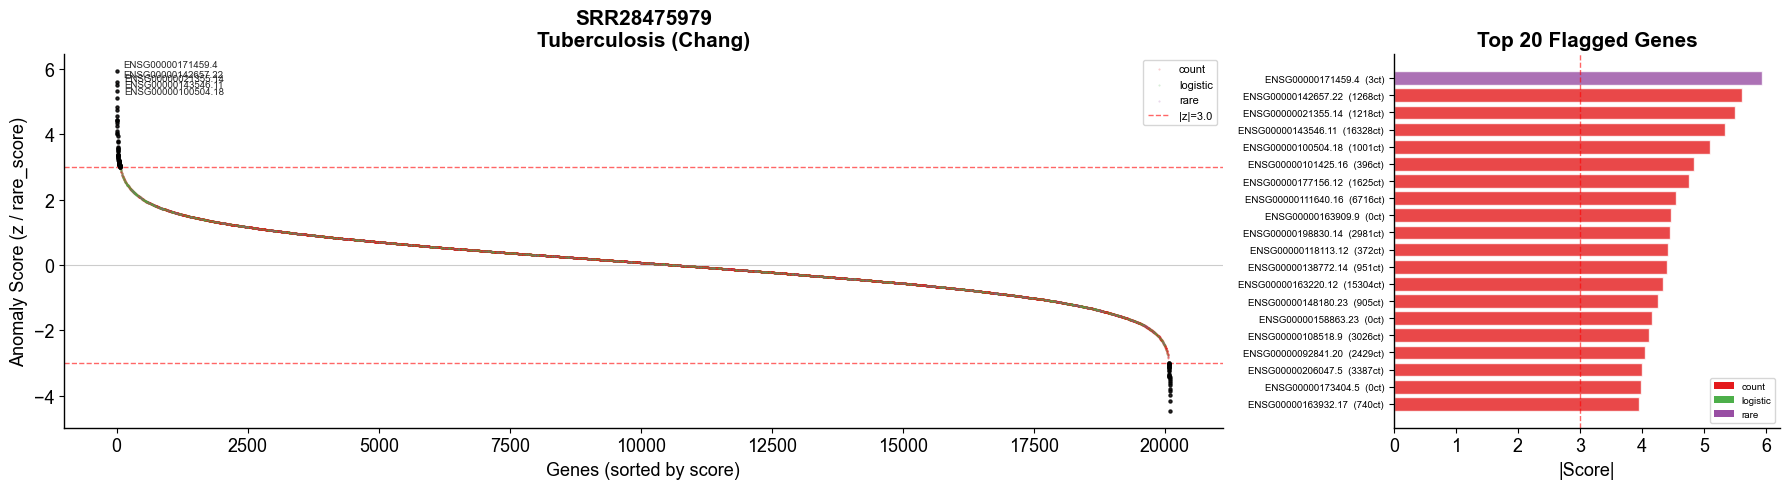

In [6]:
Z_FLAG = config.MODELING_PARAMS['z_flag']
for pheno in ['Liver Cancer (Chen)', 'Pancreatic Cancer (Moore)', 'Tuberculosis (Chang)']:
    mask = (phenotypes == pheno) & is_dis
    if not mask.any():
        print(f'{pheno}: no samples'); continue
    idx = np.where(mask)[0][1]
    sid = sample_ids[idx]
    print(f'\nScoring {pheno}: {sid}')
    df = score_sample(idx)
    flagged = df[df['score'].abs() >= Z_FLAG]
    print(f'  Flagged genes: {len(flagged)}')
    print(flagged.nlargest(5, 'score')[['gene', 'score', 'score_type', 'raw_count']].to_string(index=False))
    fig = plots.plot_sample(df, sid, pheno)
    fig.savefig(config.CV_FIG_DIR / f'score_{pheno.replace(" ", "_").replace("/", "_")}.png', bbox_inches='tight', dpi=150)
    plt.show()

In [7]:
X_dis = X_raw[dis_idx]
Y_dis = Y[dis_idx]
Z_full, Z_rare, flagged = scoring.score_full(engine, gene_names,
                                             X_dis, Y_dis, dis_names, dis_pheno)
print(f'Z matrix: {Z_full.shape}   rare: {Z_rare.shape}   flagged rows: {len(flagged):,}')

Z matrix: (913, 20097)  (10.9s)
Z matrix: (913, 20097)   rare: (913, 559)   flagged rows: 281,663


In [8]:
hc_idx = np.where(is_hc)[0]
X_hc = X_raw[hc_idx]
Y_hc = Y[hc_idx]
hc_names = [sample_ids[i] for i in hc_idx]
Z_hc = scoring.score_hc(engine, X_hc, Y_hc, gene_names, hc_names)
print(f'Z_hc matrix: {Z_hc.shape}')

Z_hc matrix: (693, 20097)
